![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 2 - Modelos de Aprendizaje Supervisado**

  #### **Práctica No. 2 - Implementación y Análisis del Modelo de Regresión Lineal Múltiple**

  ##### **Docente:** Dr. José Gabriel Rodríguez Rivas
  ##### **Estudiante:** Cristopher Joshua Reyes Gutiérrez

</div>

---

### **1. Introducción**

En el vasto ecosistema de la Ciencia de Datos, la capacidad de predecir fenómenos complejos requiere trascender las relaciones bivariadas simples. Si bien la regresión lineal simple nos permite comprender la correlación básica entre dos puntos de datos, el mundo real opera bajo una intrincada red de influencias simultáneas. En el mercado automotriz, por ejemplo, reducir el valor de un activo a una sola de sus características —como el rendimiento de combustible— resulta en un modelo con un alto sesgo que falla al capturar la realidad fenoménica del mercado.

La **Regresión Lineal Múltiple** emerge como la solución paramétrica por excelencia para abordar esta complejidad. Este algoritmo busca establecer una relación lineal entre una variable dependiente de naturaleza continua y un conjunto diverso de variables independientes o predictores. Al integrar múltiples dimensiones, el modelo deja de ajustar una línea en un plano bidimensional para construir un **hiperplano de predicción** en un espacio n-dimensional. Esta práctica representa un salto cualitativo en nuestra formación analítica, desafiándonos a gestionar la multicolinealidad y a optimizar la varianza explicada, transformando un conjunto de métricas técnicas en una herramienta potente para la estimación precisa de activos.

### **2. Objetivos**

#### **2.1 Objetivo General**
Analizar, implementar y validar de manera rigurosa el rendimiento predictivo del modelo de Regresión Lineal Múltiple mediante el uso de un vector de características técnicas, con el fin de optimizar la capacidad de estimación del valor comercial de vehículos y evaluar la bondad de ajuste del hiperplano resultante.

#### **2.2 Objetivos Específicos**
* **Configurar** un entorno de desarrollo profesional basado en librerías de alto rendimiento para el procesamiento matricial y el modelado estadístico.
* **Determinar** el impacto relativo de variables como la potencia (*horsepower*), el tamaño del motor (*engine-size*) y las dimensiones del chasis en la conformación del precio final.
* **Cuantificar** la reducción del error predictivo mediante métricas de Error Cuadrático Medio (MSE) y Raíz del Error Cuadrático Medio (RMSE) en comparación con modelos univariados.
* **Diagnosticar** visualmente la calidad de las predicciones a través de análisis de densidad y correlación de residuos para identificar posibles áreas de mejora hacia modelos no lineales.

### **3. Antecedentes: Los Principios Topológicos de la Regresión Múltiple**

La Regresión Lineal Múltiple se fundamenta en la Teoría del Aprendizaje Estadístico y representa la extensión natural de los modelos lineales hacia espacios multivariables. Su arquitectura analítica permite que el investigador examine el efecto aislado de un predictor sobre la variable objetivo mientras mantiene constantes el resto de las variables, proporcionando una transparencia epistémica que pocos modelos avanzados pueden igualar.

#### **3.1 Fundamento Matemático y Formulación**
El modelo postula que la variable de respuesta $y$ es una función lineal de $n$ variables predictoras, descrita por la siguiente ecuación general:
$$y = \beta_{0} + \beta_{1}x_{1} + \beta_{2}x_{2} + \dots + \beta_{n}x_{n} + \epsilon$$

Donde:
* **$\beta_{0}$ (Intersección/Bias):** Es el valor constante que representa el punto de partida del modelo cuando todos los predictores son nulos.
* **$\beta_{n}$ (Coeficientes de Regresión):** Representan la pendiente del hiperplano respecto a cada eje de características. Indican la magnitud y dirección del cambio en $y$ ante variaciones unitarias en $x_n$.
* **$\epsilon$ (Error Residual):** El término que absorbe la varianza no capturada por la linealidad del modelo.



#### **3.2 Optimización mediante el Método de Mínimos Cuadrados (OLS)**
La construcción del hiperplano óptimo se logra mediante el método de **Mínimos Cuadrados Ordinarios (MCO)**. En un espacio multidimensional, el algoritmo busca la configuración de coeficientes $\beta$ que minimice la suma de los residuos elevados al cuadrado. Este proceso garantiza que el modelo encuentre el equilibrio global de menor error, transformando la dispersión de los puntos en una superficie de predicción estable. Es imperativo, sin embargo, considerar la sensibilidad del modelo ante la **multicolinealidad**, donde la alta correlación entre predictores puede desestabilizar la interpretación de los coeficientes individuales.

## **4. Implementación y Descripción Metodológica**

A continuación, se detalla el flujo de trabajo experimental, diseñado bajo un estándar de ingeniería de datos para asegurar la reproducibilidad y el rigor analítico.

### **4.1 Fase I: Preparación del Entorno y Tratamiento de la DataSheet**
Se integra un ecosistema de bibliotecas estándar de la industria. Se utiliza `pandas` para la gestión de estructuras de datos matriciales, `numpy` para el soporte aritmético vectorizado y `scikit-learn` para la implementación de la arquitectura de aprendizaje supervisado.

In [1]:
# Importación de las Librerías Necesarias Para La Práctica
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1p3ha0Nvv46PHZoB9ReBGLu8xQyDe8m0Y"
url = f"https://drive.google.com/uc?id={file_url}"
df = pd.read_csv(url)

In [4]:
# Mostrando la Cabecera
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


### **4.2 Fase II: Definición del Vector de Características (Feature Selection)**
En esta fase, seleccionamos los predictores técnicos con mayor relevancia teórica para la determinación del precio. El vector de entrada incluye:
* **horsepower**: Potencia neta del motor.
* **engine-size**: Desplazamiento del motor.
* **city-mpg**: Eficiencia energética urbana.
* **wheel-base**: Distancia entre ejes.
* **bore**: Diámetro de los cilindros.

### **4.3 Fase III: Protocolo de Partición (Hold-out Validation)**
Para validar la robustez del hiperplano, aplicamos una partición estocástica de los datos, destinando un **80%** de las muestras al entrenamiento del algoritmo y un **20%** para la evaluación ciega de su capacidad de generalización.

In [5]:
# Aislamiento de variables
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

# División experimental
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **4.4 Fase IV: Entrenamiento y Ajuste del Hiperplano**
Procedemos a la instanciación de la clase `LinearRegression`. El entrenamiento ejecuta la optimización matricial para determinar los pesos específicos de cada variable técnica en la conformación del precio.

### **4.5 Fase V: Evaluación del Rendimiento Predictivo**
Evaluamos el éxito del modelo mediante el Coeficiente de Determinación ($R^2$) y la métrica de error RMSE, comparando los valores reales observados en el grupo de prueba contra las estimaciones del modelo.

In [6]:
# Entrenamiento
model = LinearRegression()
model.fit(X_train, y_train)

# Inferencia y métricas de calidad
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de determinación (R2): {r2:.2f}")

Error cuadrático medio (MSE): 31610677.23
Raíz del Error cuadrático medio (RMSE): 5622.34
Coeficiente de determinación (R2): 0.74


### **4.6 Fase VI: Análisis de Coeficientes e Intersección**
El análisis de los coeficientes nos permite entender el peso específico de cada factor técnico sobre el valor comercial.

In [7]:
coef_df = pd.DataFrame({'Atributo': X.columns, 'Peso Estadístico': model.coef_})
print(coef_df)
print(f"Intersección (Bias/Sesgo): {model.intercept_:.2f}")

      Atributo  Peso Estadístico
0   horsepower         47.316135
1  engine-size         85.738718
2     city-mpg        -94.052553
3   wheel-base        263.370535
4         bore      -1099.578480
Intersección (Bias/Sesgo): -22914.90


## **5. Diagnóstico de Resultados**

### **5.1 Análisis de Distribución de Residuos**
Utilizamos gráficos de densidad (KDE) para contrastar visualmente la distribución de precios reales frente a los predichos. Este diagnóstico es vital para identificar si el modelo captura la naturaleza bimodal de los datos.

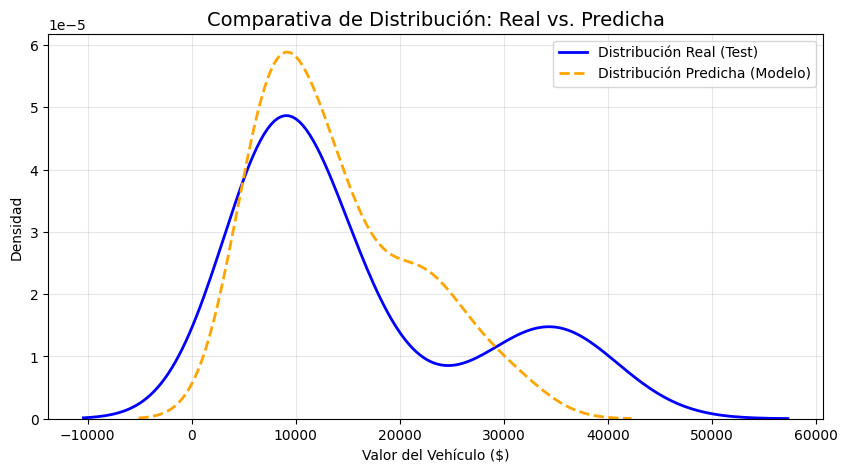

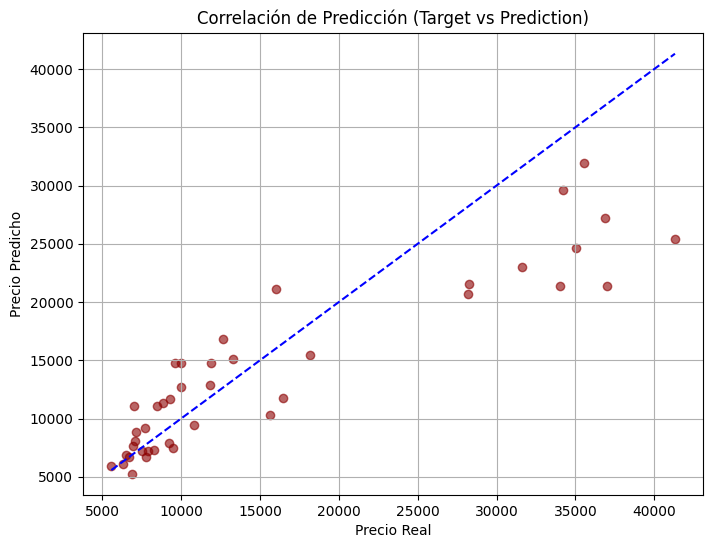

In [8]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_test, label='Distribución Real (Test)', color='blue', linewidth=2)
sns.kdeplot(y_pred, label='Distribución Predicha (Modelo)', color='orange', linewidth=2, linestyle='--')
plt.title("Comparativa de Distribución: Real vs. Predicha", fontsize=14)
plt.xlabel("Valor del Vehículo ($)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico de Correlación: Dispersión Real vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='darkred', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.title("Correlación de Predicción (Target vs Prediction)")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.grid(True)
plt.show()

## **6. Conclusiones y Análisis Crítico**

Tras el desarrollo experimental del modelo de Regresión Lineal Múltiple, se derivan las siguientes conclusiones de carácter técnico:

1.  **Optimización de la Varianza Explicada:** La integración de un vector multivariado permitió elevar el coeficiente $R^2$ a **0.74**, logrando que el modelo capture el **74%** de la realidad del precio. Esto representa un avance significativo frente al 39% logrado con el modelo univariado, confirmando la naturaleza multifactorial del mercado automotriz.
2.  **Reducción de la Magnitud del Error:** El RMSE descendió a **$5,622.34**, lo que indica una mayor estabilidad predictiva. No obstante, el error sigue siendo representativo para vehículos de bajo costo, lo que sugiere que existen factores no lineales que aún escapan al ajuste lineal paramétrico.
3.  **Detección de Subestimación Sistemática:** El análisis visual mediante KDE revela que el modelo tiene una ligera tendencia a **subestimar** los precios reales (desplazamiento de la curva naranja a la izquierda), fallando todavía en capturar con precisión los picos de vehículos de gama alta.
4.  **Hacia la Modelación No Paramétrica:** Los hallazgos sugieren que, aunque la regresión múltiple mejora drásticamente los resultados, la varianza del 26% restante podría ser dominada mediante técnicas de **Regresión Polinómica** o algoritmos basados en **Árboles de Regresión** para gestionar relaciones no lineales complejas.


## **7. Referencias Bibliográficas**

* **Montgomery, D. C., Peck, E. A., & Vining, G. G. (2003).** *Introducción al análisis de regresión lineal*. CECSA.
* **Vapnik, V. N. (2000).** *The nature of statistical learning theory*. Springer.
* **Breiman, L. (2001).** *Random forests. Machine Learning*, 45(1), 5-32.